Q3. Model Training & Supervised Evaluation [5 Marks]

In [1]:

import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

import pandas as pd
import numpy as np

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

In [2]:
# Load labeled dataset created in Q2
dataset_df = pd.read_csv(
    r"C:\Users\apurb_oi8roye\Desktop\Earth_Observation\Earth_Observation\data\processed\labeled_dataset.csv"
)

print("Dataset loaded successfully")
print(dataset_df.head())

Dataset loaded successfully
            image_name     label
0  28.2056_76.8558.png  Built-up
1  28.2056_76.8646.png  Built-up
2  28.2056_76.8734.png  Built-up
3  28.2056_76.8822.png  Built-up
4  28.2056_76.8910.png  Cropland


In [3]:

# Encode land-use labels

label_map = {
    "Built-up": 0,
    "Vegetation": 1,
    "Water": 2,
    "Cropland": 3,
    "Others": 4
}

dataset_df["label_id"] = dataset_df["label"].map(label_map)

In [4]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    dataset_df,
    test_size=0.4,
    random_state=42,
    shuffle=True
)

In [19]:
import os
from torch.utils.data import Dataset
from PIL import Image

# this step is used because image_names and label is in csv and images are in folder, we can use numpy to load all images in memory but it is not feasible
# so I made a class to get the image_name and label_id that is 0,1,2,3... and load image when needed and then convert to tensor
class LandUseDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self): # to know the size of dataset
        return len(self.df)

    def __getitem__(self, idx): # get the image name and label
        img_name = self.df.loc[idx, "image_name"]
        label = self.df.loc[idx, "label_id"]

        img_path = os.path.join(self.image_dir, img_name) # mao the image_name to its folder image
        image = Image.open(img_path).convert("RGB") # convert to RGB because cnn takes only channel-3 

        if self.transform:
            image = self.transform(image) # without this image stays as PIL image after it the shape will be (3,128,128)

        return image, label,img_name

In [6]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

image_dir = r"C:\Users\apurb_oi8roye\Desktop\Earth_Observation\Earth_Observation\data\raw\satellite\images\rgb"

train_dataset = LandUseDataset(train_df, image_dir, transform)
test_dataset  = LandUseDataset(test_df, image_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) 
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [7]:
import torch.nn as nn

# i) Train a CNN model (e.g., ResNet18 or a simple custom CNN) for land-use classification. (2 marks) 

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), # (16,128,128)
            nn.ReLU(),
            nn.MaxPool2d(2), #(16,64,64)

            #Second layer
            nn.Conv2d(16, 32, kernel_size=3, padding=1), #(32,64,64)
            nn.ReLU(),
            nn.MaxPool2d(2) #(32,32,32)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) #Optimizer updates weights,used adam.

epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss:.4f}")

Epoch 1/10 | Loss: 105.9885
Epoch 2/10 | Loss: 77.4652
Epoch 3/10 | Loss: 66.1230
Epoch 4/10 | Loss: 55.4243
Epoch 5/10 | Loss: 48.6596
Epoch 6/10 | Loss: 34.2423
Epoch 7/10 | Loss: 22.6604
Epoch 8/10 | Loss: 12.1482
Epoch 9/10 | Loss: 7.7606
Epoch 10/10 | Loss: 4.7713


In [22]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Switch model to evaluation mode
model.eval()

y_true = []
y_pred = []
image_names=[]

# Disable gradient calculation (important)
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        # Get predicted class (index of max value)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

        batch_indices = len(image_names)
        image_names.extend(
            test_df.iloc[batch_indices:batch_indices+len(labels)]["image_name"].values
        )

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ii) Evaluate using accuracy and F1-score. (2 marks)
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="weighted")

print("Test Accuracy:", accuracy)
print("Test F1-score:", f1)

Test Accuracy: 0.8346849656893325
Test F1-score: 0.8299168832265872


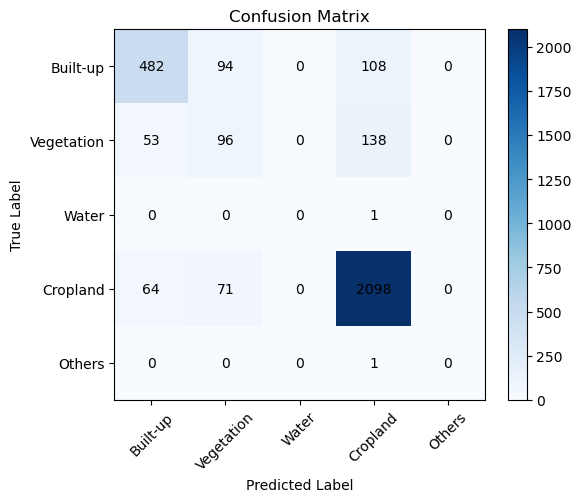

In [25]:
# iii) Display a confusion matrix and briefly interpret the results. (1 mark)
cm = confusion_matrix(y_true, y_pred)

class_names = ["Built-up", "Vegetation", "Water", "Cropland", "Others"]

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
confuse_fig=r"C:\Users\apurb_oi8roye\Desktop\Earth_Observation\Earth_Observation\Visualizations\confusion_matrix.png"
plt.savefig(confuse_fig, dpi=300)
plt.show()

Interpretation of result 
=> Overall the model perform well with dominant classes yet get confuse for minority classes.
==> we can balance the data by increasing class weight or use Resnet18 to improve the accuracy

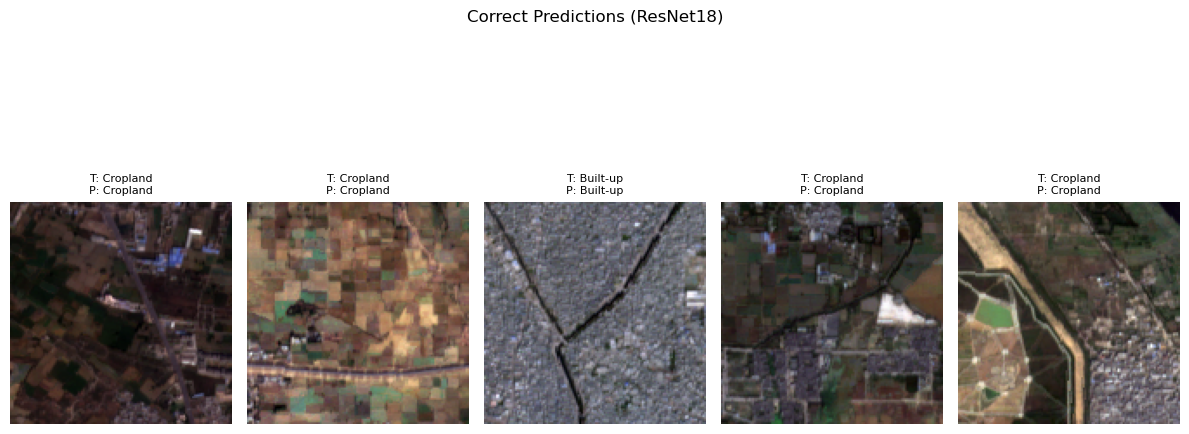

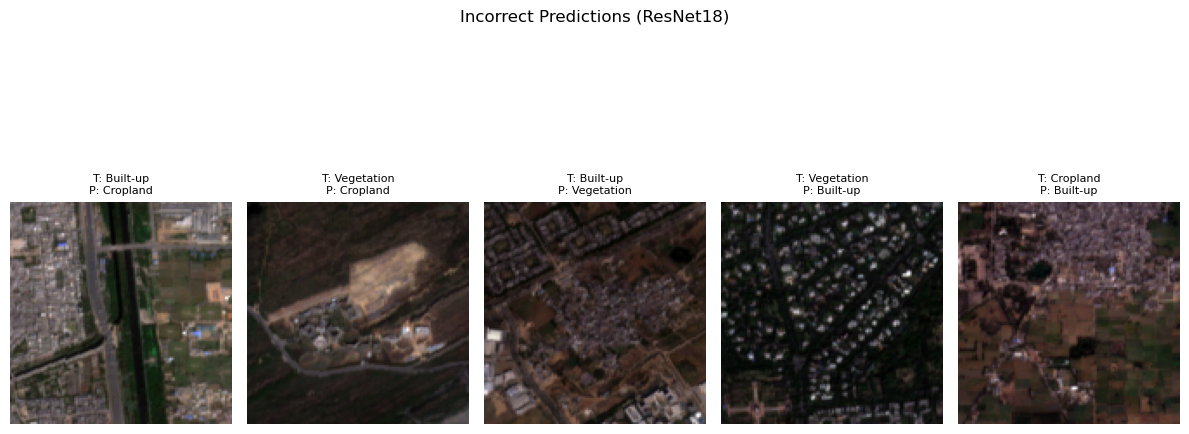

In [27]:
# ploting 5 correct and 5 incorrect predictions with images and labels

correct_indices = []
incorrect_indices = []

for i in range(len(y_true)):
    if y_true[i] == y_pred[i]:
        correct_indices.append(i)
    else:
        incorrect_indices.append(i)

import matplotlib.pyplot as plt
from PIL import Image
import os

class_names = list(label_map.keys())
image_dir = r"C:\Users\apurb_oi8roye\Desktop\Earth_Observation\Earth_Observation\data\raw\satellite\images\rgb"

def plot_samples(indices, title):
    plt.figure(figsize=(12, 6))
    
    for i, idx in enumerate(indices[:5]):
        img_path = os.path.join(image_dir, image_names[idx])
        img = Image.open(img_path)

        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"T: {class_names[y_true[idx]]}\nP: {class_names[y_pred[idx]]}",
            fontsize=8
        )

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
plot_samples(correct_indices, "Correct Predictions (ResNet18)")
plot_samples(incorrect_indices, "Incorrect Predictions (ResNet18)")